In [ ]:
import pandas as pd

df_time = pd.read_csv("results/timing.csv")
df_perf = pd.read_csv("results/perf_stats.csv")

df = pd.merge(df_time, df_perf, on=["kernel", "n", "bindir"])
df

,kernel,n,bindir,time_s,checksum,instructions,cycles,cache-references,cache-misses
0,dot,64,bin/O0,1.022000e-06,1.543980e+01,2870724,1866181,77217,22000
1,dot,256,bin/O0,2.615000e-06,6.597160e+01,3015727,2001445,75527,20492
2,dot,1024,bin/O0,9.748000e-06,2.637870e+02,3718163,2239741,72213,20151
3,dot,2048,bin/O0,1.634100e-05,5.160940e+02,4613952,2713458,67558,21556
4,matmul_ijk,64,bin/O0,3.044650e-03,6.575260e+04,45831716,15536733,488536,219233
...,...,...,...,...,...,...,...,...,...
91,matvec_col,2048,bin/O3fast,2.724380e-02,1.054050e+06,277235231,248760866,11281777,5075178
92,matvec_row,64,bin/O3fast,5.810000e-07,1.030550e+03,2976533,2487620,75645,19246
93,matvec_row,256,bin/O3fast,1.263400e-05,1.710820e+04,6942676,4627155,123101,24083
94,matvec_row,1024,bin/O3fast,3.892890e-04,2.652660e+05,70210854,35390984,912961,33521


In [8]:
df.groupby("bindir")["time_s"].mean()

bindir
bin/O0          10.692006
bin/O2          13.116881
bin/O3fast       8.972685
bin/O3native     9.829345
Name: time_s, dtype: float64

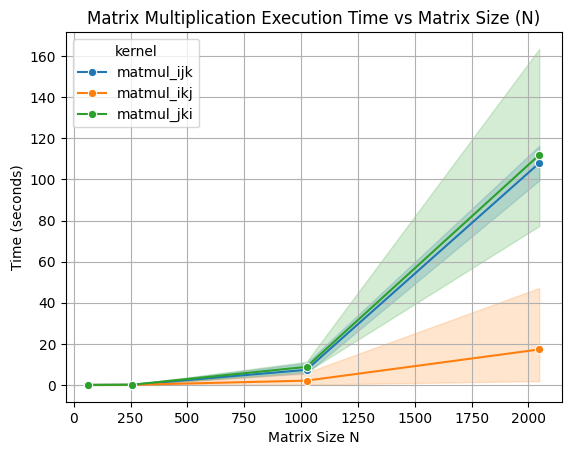

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

df_matmul = df[df['kernel'].str.contains('matmul')]
sns.lineplot(data=df_matmul, x='n', y='time_s', hue='kernel', marker='o')

plt.title('Matrix Multiplication Execution Time vs Matrix Size (N)')
plt.xlabel('Matrix Size N')
plt.ylabel('Time (seconds)')
plt.grid(True)

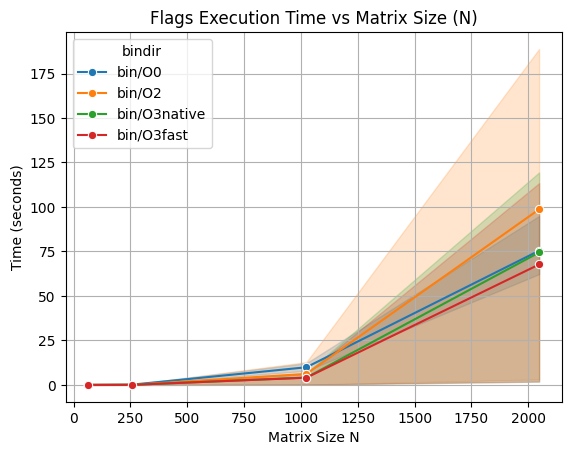

In [27]:
sns.lineplot(data=df_matmul, x='n', y='time_s', hue='bindir', marker='o')

plt.title('Flags Execution Time vs Matrix Size (N)')
plt.xlabel('Matrix Size N')
plt.ylabel('Time (seconds)')
plt.grid(True)

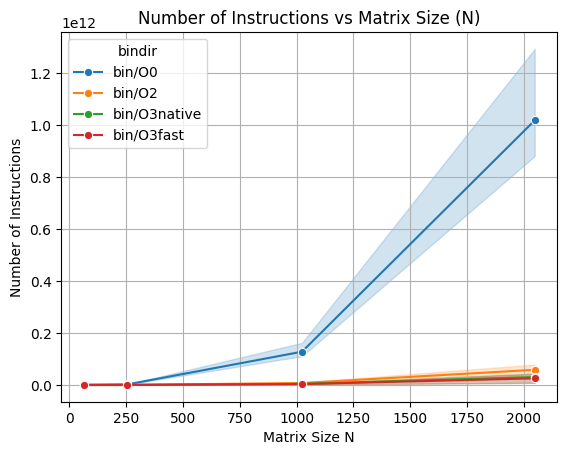

In [32]:
sns.lineplot(data=df_matmul, x='n', y='instructions', hue='bindir', marker='o')

plt.title('Number of Instructions vs Matrix Size (N)')
plt.xlabel('Matrix Size N')
plt.ylabel('Number of Instructions')
plt.grid(True)

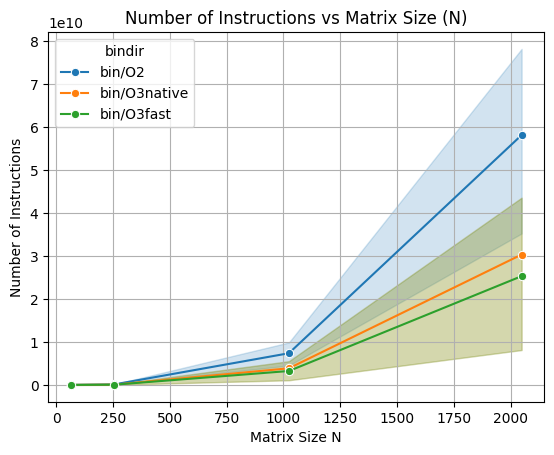

In [42]:
sns.lineplot(data=df_matmul[~(df_matmul["bindir"] == "bin/O0")], x='n', y='instructions', hue='bindir', marker='o')

plt.title('Number of Instructions vs Matrix Size (N)')
plt.xlabel('Matrix Size N')
plt.ylabel('Number of Instructions')
plt.grid(True)